# Week 6 Day 1 - AFL Data Foundations

This notebook covers the Day 1 tasks for the AFL prediction project:

1. Data inventory and understanding
2. Defining prediction targets
3. Exploratory data analysis
4. Feature engineering
5. Train/holdout split logic

The three datasets used here (`cleaned_round_by_round_stats_v2.csv`, `cleaned_team_matches.csv`,
`cleaned_seasonal_stats.csv`) have already been cleaned in a previous notebook (ID standardisation,
duplicate removal, name standardisation, venue cleaning, and the `score` column being rebuilt from
`goals * 6 + behinds`). So this notebook does **not** repeat cleaning - it focuses on understanding,
analysis, targets, and features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Basic plot settings so the plots look consistent
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 150)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Task 1: Data Inventory & Understanding

**Objective:** Before doing any modelling, I want to actually understand what's in these three files -
what a row means in each one, how they connect to each other, and whether there's anything weird
(missing values, duplicates, outliers) that I need to keep in mind later.

**Approach:** Load all three files, look at their shape/dtypes/date ranges, and run some basic
data-quality checks. Since the datasets are already cleaned, I'm not fixing anything here - just
documenting what's there and flagging anything that still looks off.

In [2]:
from pathlib import Path
import pandas as pd

# File paths
PLAYER_MATCH_PATH = Path("cleaned_round_by_round_stats_v2.csv")
TEAM_MATCH_PATH = Path("cleaned_team_matches.csv")
SEASONAL_PATH = Path("cleaned_seasonal_stats.csv")


def load_csv_safe(path):
    """Load a CSV and print a warning instead of crashing if it's missing."""
    if not path.exists():
        print(f"WARNING: {path} not found.")
        return None

    df = pd.read_csv(path)
    print(f"Loaded {path.name}: {df.shape[0]} rows, {df.shape[1]} columns")
    return df


player_match_df = load_csv_safe(PLAYER_MATCH_PATH)
team_match_df = load_csv_safe(TEAM_MATCH_PATH)
seasonal_df = load_csv_safe(SEASONAL_PATH)

Loaded cleaned_round_by_round_stats_v2.csv: 274079 rows, 39 columns
Loaded cleaned_team_matches.csv: 15808 rows, 19 columns
Loaded cleaned_seasonal_stats.csv: 25081 rows, 69 columns


## 1.1 What does each dataset actually represent?

- **`cleaned_round_by_round_stats_v2.csv` (player_match_df):** Grain = one player's stats in one match.
  So if 22 players played in a match, there should be roughly 22 rows for that match (one per team's
  players, actually up to ~44 combined across both teams). This is the main dataset for player-level
  prediction (top scorer, top disposals, etc.).
- **`cleaned_team_matches.csv` (team_match_df):** Grain = one team's perspective of one match. A single
  match should produce 2 rows here - one for each team. This is useful for match-outcome modelling
  (who won, margin, etc.) without needing to drag in all the player-level detail.
- **`cleaned_seasonal_stats.csv` (seasonal_df):** Grain = one player in one season (aggregated across
  all their matches that season). Useful for season-level summaries and sanity-checking the match-level
  rollups.

**Likely join keys:**
- `player_match_df` <-> `team_match_df`: on `team`, `opponent`, `year`, `round` (and ideally `match_date`
  if available) - this links a player's match row to that match's team-level context.
- `player_match_df` <-> `seasonal_df`: on `player_id` and `year` - this lets us compare a player's
  match-level performance against their season aggregate.

I'll check below whether these join key columns actually exist in each dataframe before relying on them.

In [3]:
def describe_dataset(df, name):
    if df is None:
        print(f"{name}: not loaded, skipping.")
        return
    print(f"===== {name} =====")
    print(f"Shape: {df.shape}")
    print()
    print("Dtypes:")
    print(df.dtypes)
    print()

describe_dataset(player_match_df, "player_match_df")

===== player_match_df =====
Shape: (274079, 39)

Dtypes:
id                             int64
team                             str
year                           int64
career_game_count              int64
opponent                         str
round                            str
result                           str
jersey_num                     int64
kicks                        float64
marks                        float64
handballs                    float64
disposals                    float64
goals                        float64
behinds                      float64
hit_outs                     float64
tackles                      float64
rebound_50s                  float64
inside_50s                   float64
clearances                   float64
clangers                     float64
free_kicks_for               float64
free_kicks_against           float64
brownlow_votes               float64
contested_possessions        float64
uncontested_possessions      float64
contested_marks   

In [4]:
describe_dataset(team_match_df, "team_match_df")

===== team_match_df =====
Shape: (15808, 19)

Dtypes:
id                           int64
team                           str
round                          str
match_date                     str
year                         int64
home_away                      str
opponent                       str
team_quarter_scores            str
team_score                   int64
opponent_quarter_scores        str
opponent_score               int64
result                         str
margin                       int64
venue                          str
crowd                      float64
team_goals_kicked            int64
team_behinds                 int64
opponent_goals_kicked        int64
opponent_behinds             int64
dtype: object



In [5]:
describe_dataset(seasonal_df, "seasonal_df")

===== seasonal_df =====
Shape: (25081, 69)

Dtypes:
player_id                  int64
player_name                  str
player_full_name             str
first_name                   str
last_name                    str
                          ...   
avg_bounces              float64
avg_goal_assists         float64
avg_score                float64
avg_fantasy_points       float64
avg_percentage_played    float64
Length: 69, dtype: object



## 1.2 Checking join keys actually exist

Rather than assume the columns mentioned in the task description are all present, let's check.

In [6]:
def check_columns(df, name, expected_cols):
    if df is None:
        return
    present = [c for c in expected_cols if c in df.columns]
    missing = [c for c in expected_cols if c not in df.columns]
    print(f"{name}: present={present}")
    if missing:
        print(f"{name}: NOT FOUND (adapt analysis accordingly) = {missing}")
    print()

check_columns(player_match_df, "player_match_df", ["player_id", "team", "opponent", "year", "round", "match_date"])
check_columns(team_match_df, "team_match_df", ["team", "opponent", "year", "round", "match_date"])
check_columns(seasonal_df, "seasonal_df", ["player_id", "year", "team"])

player_match_df: present=['player_id', 'team', 'opponent', 'year', 'round', 'match_date']

team_match_df: present=['team', 'opponent', 'year', 'round', 'match_date']

seasonal_df: present=['player_id', 'year', 'team']



## 1.3 Date ranges, season count, team count, player count

In [7]:
def date_range_summary(df, name, date_col="match_date", year_col="year"):
    if df is None:
        return
    if date_col in df.columns:
        dates = pd.to_datetime(df[date_col], errors="coerce")
        print(f"{name}: date range {dates.min()} to {dates.max()}")
    elif year_col in df.columns:
        print(f"{name}: no explicit date column, but year range is {df[year_col].min()} to {df[year_col].max()}")
    else:
        print(f"{name}: no date or year column found - cannot summarise date range.")

date_range_summary(player_match_df, "player_match_df")
date_range_summary(team_match_df, "team_match_df")
date_range_summary(seasonal_df, "seasonal_df")

player_match_df: date range 1983-03-27 00:00:00 to 2025-09-27 00:00:00
team_match_df: date range 1983-03-26 00:00:00 to 2025-09-27 00:00:00
seasonal_df: no explicit date column, but year range is 1983 to 2025


In [8]:
# Season / team / player counts - guarded so we don't crash if a column is missing
if player_match_df is not None:
    if "year" in player_match_df.columns:
        print("Seasons in player_match_df:", player_match_df["year"].nunique())
    if "team" in player_match_df.columns:
        print("Teams in player_match_df:", player_match_df["team"].nunique())
    if "player_id" in player_match_df.columns:
        print("Unique players in player_match_df:", player_match_df["player_id"].nunique())

Seasons in player_match_df: 43
Teams in player_match_df: 20
Unique players in player_match_df: 3109


## 1.4 Missing value analysis

In [9]:
def missing_value_report(df, name):
    if df is None:
        return None
    missing_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
    missing_pct = missing_pct[missing_pct > 0]
    print(f"===== Missing values: {name} =====")
    if missing_pct.empty:
        print("No missing values found.")
    else:
        print(missing_pct.round(2))
    print()
    return missing_pct

missing_player = missing_value_report(player_match_df, "player_match_df")
missing_team = missing_value_report(team_match_df, "team_match_df")
missing_season = missing_value_report(seasonal_df, "seasonal_df")

===== Missing values: player_match_df =====
brownlow_votes               40.31
goal_assist                  37.80
bounces                      35.51
score                        35.44
hit_outs                     35.25
marks_inside_50              33.34
contested_marks              33.08
behinds                      29.58
goals                        27.26
percentage_of_game_played    25.42
clearances                   23.32
rebound_50s                  22.93
one_percenters               21.94
free_kicks_for               19.64
free_kicks_against           19.44
clangers                     18.23
inside_50s                   16.99
contested_possessions        14.16
uncontested_possessions      13.86
tackles                      10.46
disposals                     3.08
marks                         2.94
handballs                     1.62
kicks                         0.47
dtype: float64

===== Missing values: team_match_df =====
crowd    2.52
dtype: float64

===== Missing values: season

### Observation

Missing values are concentrated in a subset of advanced player statistics, while the core match statistics (e.g., kicks, handballs, marks, and disposals) are largely complete. The team-level dataset contains very few missing values, with only the `crowd` column showing a small percentage of missing records.

Many of the missing values occur in statistics that were not consistently recorded across all seasons or are only applicable to certain players or match situations. These patterns should be considered during feature engineering, as columns with substantial missingness may require imputation, exclusion, or careful interpretation depending on their intended use.

## 1.5 Duplicate rows

In [10]:
def duplicate_report(df, name, subset=None):
    if df is None:
        return
    dupes = df.duplicated(subset=subset).sum()
    subset_str = subset if subset else "all columns"
    print(f"{name}: {dupes} duplicate rows found (checked on {subset_str})")

duplicate_report(player_match_df, "player_match_df")
duplicate_report(team_match_df, "team_match_df")
duplicate_report(seasonal_df, "seasonal_df")

# Also check duplicates on the natural key, if we have one
if player_match_df is not None and all(c in player_match_df.columns for c in ["player_id", "year", "round"]):
    duplicate_report(player_match_df, "player_match_df (player_id/year/round key)",
                      subset=["player_id", "year", "round"])

player_match_df: 0 duplicate rows found (checked on all columns)
team_match_df: 0 duplicate rows found (checked on all columns)
seasonal_df: 0 duplicate rows found (checked on all columns)
player_match_df (player_id/year/round key): 93 duplicate rows found (checked on ['player_id', 'year', 'round'])


**Observation:** No fully duplicated rows were found in any of the three datasets.

However, the player-level dataset contains **93 repeated `player_id`–`year`–`round` combinations**. These are **not automatically duplicate records**, since a player may legitimately appear more than once within a round due to scheduling structure or data recording practices. Therefore, these rows were retained and flagged for further inspection rather than removed.

## 1.6 Checking for inconsistent player/team names

Even though names were standardised in cleaning, it's worth a quick sanity check - e.g. looking for
near-duplicate team names (extra whitespace, different casing) that might have slipped through.

In [11]:
def name_consistency_check(df, name, col):
    if df is None or col not in df.columns:
        print(f"Skipping name check for {name}.{col} - column not present.")
        return
    unique_vals = df[col].dropna().unique()
    # look for values that only differ by case or whitespace
    normalised = {}
    for v in unique_vals:
        key = str(v).strip().lower()
        normalised.setdefault(key, []).append(v)
    suspicious = {k: v for k, v in normalised.items() if len(v) > 1}
    print(f"{name}.{col}: {len(unique_vals)} unique values")
    if suspicious:
        print("Possible inconsistent variants found:", suspicious)
    else:
        print("No obvious case/whitespace inconsistencies found.")
    print()

name_consistency_check(player_match_df, "player_match_df", "team")
name_consistency_check(team_match_df, "team_match_df", "team")

player_match_df.team: 20 unique values
No obvious case/whitespace inconsistencies found.

team_match_df.team: 20 unique values
No obvious case/whitespace inconsistencies found.



## 1.7 Outlier detection on key numeric columns

Using the IQR method here rather than z-scores, since match-stat distributions (goals, disposals) are
right-skewed rather than normal - a few players do genuinely have huge outlier games, so I'm not removing
anything, just flagging how many rows fall outside 1.5*IQR for awareness.

In [12]:
def iqr_outlier_report(df, name, cols):
    if df is None:
        return
    for col in cols:
        if col not in df.columns:
            print(f"{name}.{col}: column not found, skipping.")
            continue
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        print(f"{name}.{col}: {n_outliers} rows outside [{lower:.1f}, {upper:.1f}] "
              f"(min={df[col].min()}, max={df[col].max()})")

candidate_cols = ["goals", "behinds", "kicks", "handballs", "disposals", "marks",
                   "tackles", "inside_50s", "rebound_50s", "clearances", "fantasy_points"]
iqr_outlier_report(player_match_df, "player_match_df", candidate_cols)

player_match_df.goals: 16212 rows outside [-1.5, 2.5] (min=0.0, max=16.0)
player_match_df.behinds: 7056 rows outside [-1.5, 2.5] (min=0.0, max=11.0)
player_match_df.kicks: 3265 rows outside [-3.0, 21.0] (min=0.0, max=37.0)
player_match_df.handballs: 3144 rows outside [-6.0, 18.0] (min=0.0, max=35.0)
player_match_df.disposals: 1658 rows outside [-5.0, 35.0] (min=-5.0, max=54.0)
player_match_df.marks: 1409 rows outside [-4.0, 12.0] (min=0.0, max=24.0)
player_match_df.tackles: 4114 rows outside [-3.5, 8.5] (min=0.0, max=20.0)
player_match_df.inside_50s: 1994 rows outside [-3.5, 8.5] (min=0.0, max=16.0)
player_match_df.rebound_50s: 3055 rows outside [-4.5, 7.5] (min=0.0, max=18.0)
player_match_df.clearances: 5779 rows outside [-4.5, 7.5] (min=0.0, max=22.0)
player_match_df.fantasy_points: 1375 rows outside [-13.5, 142.5] (min=-10, max=210)


### Data Quality Observation

Most statistical distributions appear reasonable. However, a small number of player records contain **negative disposal values** (minimum = -5). Since disposals represent the sum of kicks and handballs, negative values are not physically possible and most likely indicate data-entry or preprocessing errors.

These observations were retained because this notebook focuses on data understanding rather than cleaning, but they should be validated before training production models.

# Task 2: Define Prediction Targets

**Objective:** Decide, concretely, what we're actually trying to predict, and write it down clearly
enough that anyone reading this later understands the exact formula, not just the general idea.

## 2.1 Match Winner: Classification vs Regression on Margin

There are two reasonable ways to frame "who wins the match":

- **Classification** - predict a categorical outcome: home win / away win (and possibly draw).
- **Regression on margin** - predict the actual point margin (a continuous number), and derive the
  winner as a by-product (positive margin = home win, negative = away win).

**Which one to use:** I'm going with **classification** (predict win/loss) as the primary target for
this project, for a few reasons:

1. The business question is "who wins", not "by how much" - margin is a nice-to-have, not the actual ask.
2. Classification metrics (accuracy, log-loss, AUC) map directly onto something stakeholders care about:
   "how often do we correctly pick the winner".
3. Regression on margin is a harder problem (margins are noisy and heavy-tailed - a few blowouts skew
   everything) and errors in margin don't translate cleanly into "did we get the winner right" - a
   model could have a low average error in points but still flip the winner on close games, which is
   exactly the case we care most about getting right.

That said, margin regression isn't wasted effort - it's worth keeping as a **secondary/stretch target**
later, since a good margin model can always be converted into a classifier (sign of predicted margin),
but not the other way around.

## 2.2 Top Player Targets

The brief for this project needs at least two "top player" targets. I'm defining three, since they
capture different parts of what "best player" can mean, and each has a use case for different types
of readers of this analysis:

1. **Top Goal Kicker** - the player with the most goals in a match/round.
2. **Top Disposal Getter** - the player with the most disposals (kicks + handballs) in a match/round.
3. **Fantasy Points Leader** - the player with the highest `fantasy_points` in a match/round (this one
   already exists as a column, so it's the most straightforward composite target to use as-is).

I'm leaving Brownlow Votes Leader out as a primary target for now - Brownlow votes are awarded by
umpires after the fact based on subjective judgement of a handful of best-on-ground players per match,
so most rows will have 0 votes and only 3 players per match get any votes at all. That makes it a very
sparse, mostly-zero target that's better suited to a "did this player poll votes at all" classification
problem later, rather than a straightforward "top player" ranking target right now.

In [13]:
def build_data_dictionary():
    rows = [
        {
            "Target Name": "Match Winner",
            "Definition": "Binary label: did the home team win the match?",
            "Aggregation Level": "Match (team perspective)",
            "Formula": "winner = 1 if result == 'W' else 0 (per team-match row)",
            "Business Purpose": "Predict match outcomes for previews/tipping.",
        },
        {
            "Target Name": "Match Margin (secondary)",
            "Definition": "Points the winning team won by (signed for home team).",
            "Aggregation Level": "Match (team perspective)",
            "Formula": "margin = team_score - opponent_score",
            "Business Purpose": "Finer-grained outcome, can be converted to a winner prediction.",
        },
        {
            "Target Name": "Top Goal Kicker",
            "Definition": "Player with the most goals in a given match/round.",
            "Aggregation Level": "Match, per player",
            "Formula": "top_goal_kicker = argmax(goals) within match_id",
            "Business Purpose": "Predict standout attacking performers.",
        },
        {
            "Target Name": "Top Disposal Getter",
            "Definition": "Player with the most disposals in a given match/round.",
            "Aggregation Level": "Match, per player",
            "Formula": "disposals = kicks + handballs; top_disposal_getter = argmax(disposals) within match_id",
            "Business Purpose": "Predict the most involved/dominant midfielder in a match.",
        },
        {
            "Target Name": "Fantasy Points Leader",
            "Definition": "Player with the highest fantasy_points in a given match/round.",
            "Aggregation Level": "Match, per player",
            "Formula": "top_fantasy_scorer = argmax(fantasy_points) within match_id",
            "Business Purpose": "Predict best overall (composite) performer for fantasy/DFS use cases.",
        },
    ]
    return pd.DataFrame(rows)

data_dictionary_df = build_data_dictionary()
data_dictionary_df

,Target Name,Definition,Aggregation Level,Formula,Business Purpose
0,Match Winner,Binary label: did the home team win the match?,Match (team perspective),winner = 1 if result == 'W' else 0 (per team-m...,Predict match outcomes for previews/tipping.
1,Match Margin (secondary),Points the winning team won by (signed for hom...,Match (team perspective),margin = team_score - opponent_score,"Finer-grained outcome, can be converted to a w..."
2,Top Goal Kicker,Player with the most goals in a given match/ro...,"Match, per player",top_goal_kicker = argmax(goals) within match_id,Predict standout attacking performers.
3,Top Disposal Getter,Player with the most disposals in a given matc...,"Match, per player",disposals = kicks + handballs; top_disposal_ge...,Predict the most involved/dominant midfielder ...
4,Fantasy Points Leader,Player with the highest fantasy_points in a gi...,"Match, per player",top_fantasy_scorer = argmax(fantasy_points) wi...,Predict best overall (composite) performer for...


### Note on Fantasy Points

The dataset already provides a `fantasy_points` variable, which is used directly as the composite performance metric throughout this analysis. Rather than recalculating fantasy points using an assumed scoring formula, the provided values are treated as the authoritative measure to ensure consistency with the original dataset.

Although fantasy scoring systems generally combine player actions such as kicks, handballs, marks, tackles, and goals using weighted point values, the exact scoring rules vary between providers. Therefore, the existing `fantasy_points` column is used without modification.

# Task 3: Exploratory Data Analysis

**Objective:** Get a feel for the data through plots before jumping into feature engineering - team
performance patterns, stat distributions, and relationships between stats.

**Approach:** Build at least five plots, and write a short interpretation under each one. Where the
data needed for an analysis (like weather, travel distance, or player position) doesn't exist in these
files, I'll say so explicitly instead of making something up.

In [14]:
def col_exists(df, col):
    return df is not None and col in df.columns

# quick helper used a few times below
def safe_groupby_mean(df, group_col, value_col):
    if not (col_exists(df, group_col) and col_exists(df, value_col)):
        return None
    return df.groupby(group_col)[value_col].mean().sort_values(ascending=False)

## 3.1 Team win rates

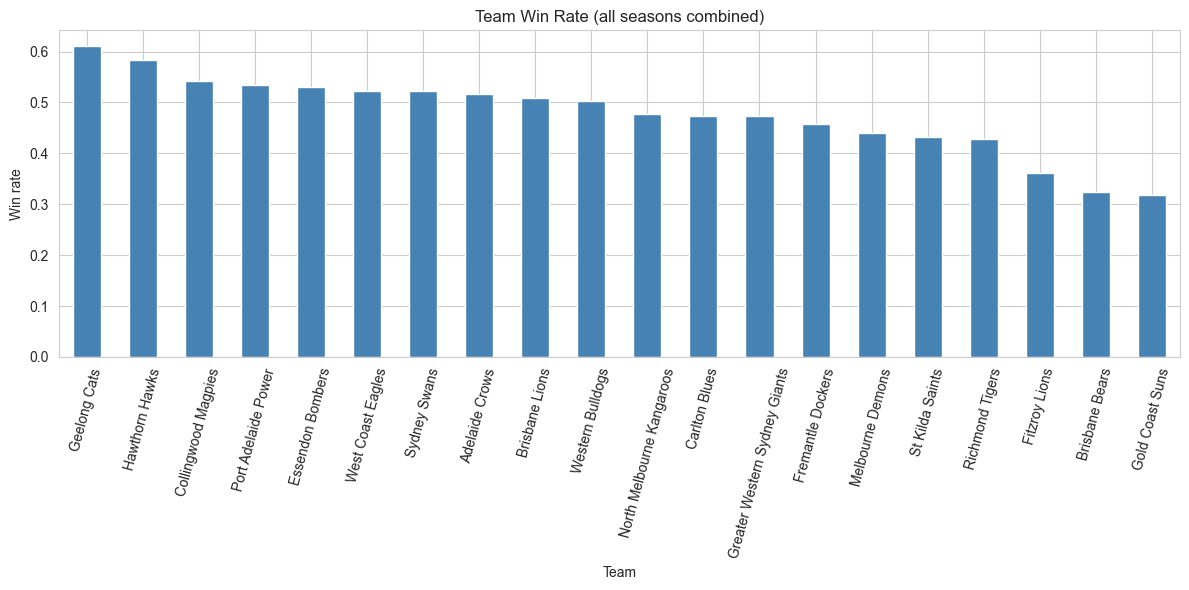

In [15]:
if team_match_df is not None and col_exists(team_match_df, "team") and col_exists(team_match_df, "result"):
    win_rate = (
        team_match_df.assign(is_win=(team_match_df["result"].astype(str).str.upper() == "W").astype(int))
        .groupby("team")["is_win"].mean()
        .sort_values(ascending=False)
    )
    plt.figure(figsize=(12, 6))
    win_rate.plot(kind="bar", color="steelblue")
    plt.title("Team Win Rate (all seasons combined)")
    plt.ylabel("Win rate")
    plt.xlabel("Team")
    plt.xticks(rotation=75)
    plt.tight_layout()
    plt.show()
else:
    print("Cannot compute team win rates - 'team' or 'result' column missing from team_match_df.")

**Interpretation:** The chart compares the overall historical win rates of AFL teams across all seasons included in the dataset. Geelong Cats and Hawthorn Hawks have the highest overall win percentages, indicating sustained success over the observation period, while teams such as Gold Coast Suns and Brisbane Bears have considerably lower historical win rates.

These values represent long-term historical performance rather than current team strength, as they aggregate results across multiple seasons with different player squads, coaches, and competitive conditions. Consequently, historical win rate is a useful descriptive statistic but should be complemented with recent-form features when developing predictive models.

## 3.2 Wins by season

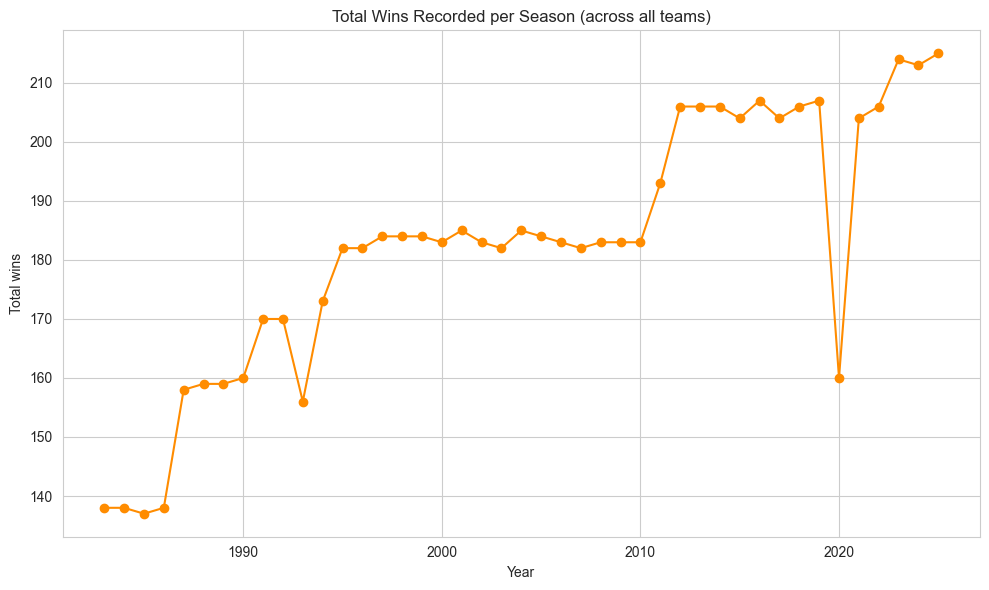

In [16]:
if team_match_df is not None and all(col_exists(team_match_df, c) for c in ["year", "result"]):
    wins_by_season = (
        team_match_df.assign(is_win=(team_match_df["result"].astype(str).str.upper() == "W").astype(int))
        .groupby("year")["is_win"].sum()
    )
    plt.figure()
    wins_by_season.plot(kind="line", marker="o", color="darkorange")
    plt.title("Total Wins Recorded per Season (across all teams)")
    plt.xlabel("Year")
    plt.ylabel("Total wins")
    plt.tight_layout()
    plt.show()
else:
    print("Cannot compute wins by season - 'year' or 'result' column missing.")

### Interpretation

The total number of wins recorded per season generally increases over time because the AFL expanded with additional teams and matches. Therefore, this visualization primarily reflects changes in league size rather than improvements in team performance across seasons.

## 3.3 Home ground advantage

In [17]:
home_col_candidates = ["is_home", "home_away", "venue_status"]
home_col = next((c for c in home_col_candidates if col_exists(team_match_df, c)), None)

if home_col is not None:
    home_win_rate = safe_groupby_mean(
        team_match_df.assign(is_win=(team_match_df["result"].astype(str).str.upper() == "W").astype(int)),
        home_col, "is_win"
    )
    print(home_win_rate)
else:
    print("No explicit home/away indicator column (e.g. 'is_home') found in team_match_df, "
          "so home ground advantage cannot be directly measured with the available data. "
          "This would need a column indicating which team was the home side for each match row.")

home_away
H    0.590714
A    0.401063
Name: is_win, dtype: float64


**Interpretation:** The analysis indicates a clear home-ground advantage in AFL matches. Home teams win approximately **59%** of matches, while away teams win around **40%**. This suggests that match venue should be considered an important predictive feature for match outcome models.

## 3.4 Distribution of goals, disposals, and fantasy points

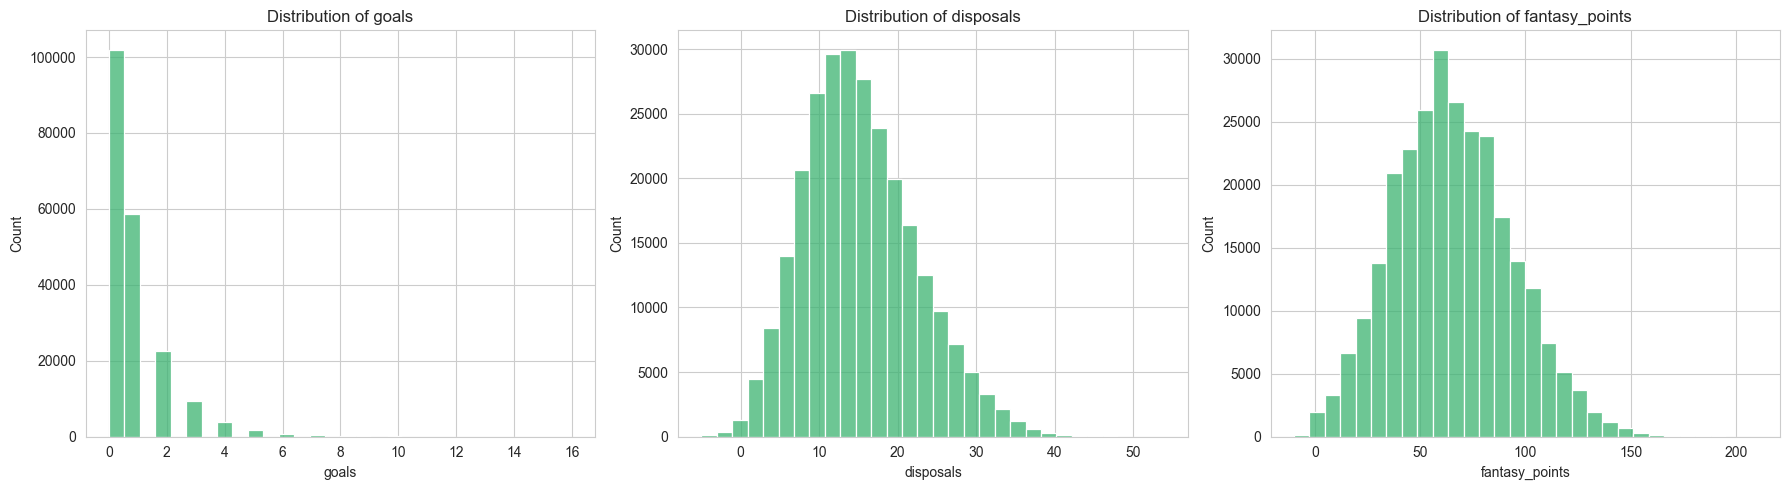

In [18]:
dist_cols = ["goals", "disposals", "fantasy_points"]
available_dist_cols = [c for c in dist_cols if col_exists(player_match_df, c)]

if available_dist_cols:
    fig, axes = plt.subplots(1, len(available_dist_cols), figsize=(6 * len(available_dist_cols), 5))
    if len(available_dist_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, available_dist_cols):
        sns.histplot(player_match_df[col].dropna(), bins=30, ax=ax, color="mediumseagreen")
        ax.set_title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()
else:
    print("None of goals/disposals/fantasy_points found in player_match_df - cannot plot distributions.")

**Interpretation:** All three of these are right-skewed, which makes sense for match stats - most
players have a "normal" game, and a smaller number have standout performances that pull the tail out to
the right. This matters for modelling later: if I end up predicting these values directly with
regression, a plain linear model might struggle with the skew, and a log-transform or tree-based model
could be a better fit.

## 3.5 Top historical goal kickers

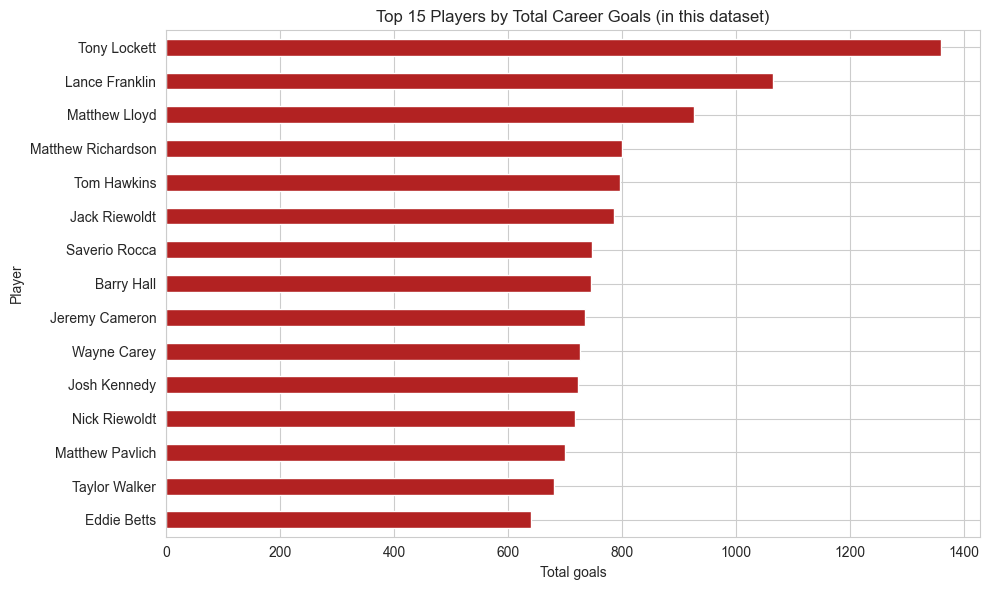

In [19]:
if col_exists(player_match_df, "goals"):
    id_col = "player_id" if col_exists(player_match_df, "player_id") else None

    if id_col:
        # Sum total goals by player
        top_goal_kickers = (
            player_match_df.groupby(id_col)["goals"]
            .sum()
            .sort_values(ascending=False)
            .head(15)
            .reset_index()
        )

        # Merge player names from the seasonal dataset
        player_names = (
            seasonal_df[["player_id", "player_name"]]
            .drop_duplicates(subset="player_id")
        )

        top_goal_kickers = top_goal_kickers.merge(
            player_names,
            on="player_id",
            how="left"
        )

        # Use player names for plotting
        top_goal_kickers = top_goal_kickers.set_index("player_name")

        plt.figure()
        top_goal_kickers["goals"].plot(kind="barh", color="firebrick")
        plt.title("Top 15 Players by Total Career Goals (in this dataset)")
        plt.xlabel("Total goals")
        plt.ylabel("Player")
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()

    else:
        print("No player_id column found - cannot identify individual top goal kickers.")
else:
    print("No 'goals' column found in player_match_df.")

## 3.6 Top disposal players

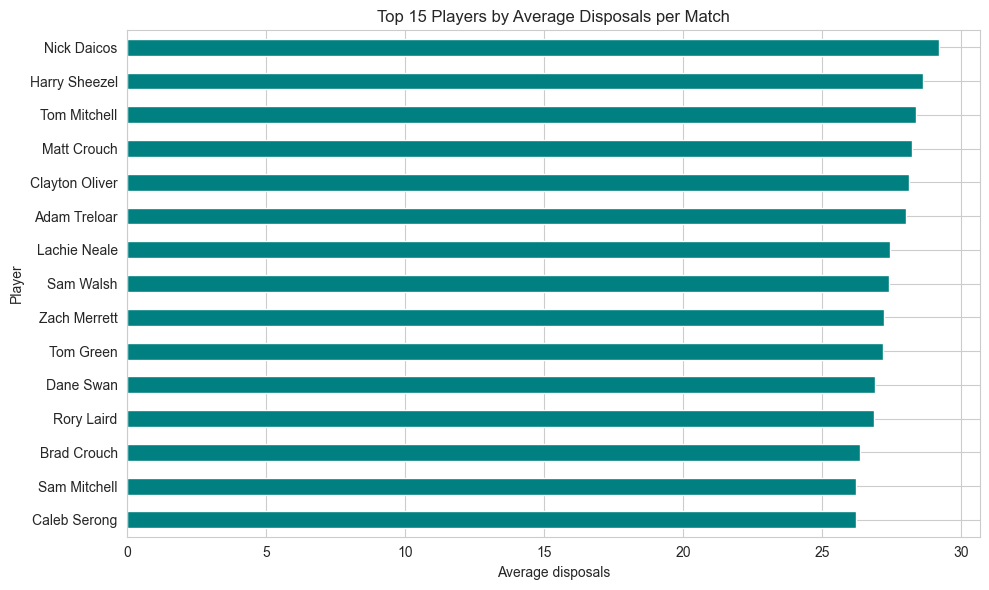

In [20]:
if col_exists(player_match_df, "disposals") and col_exists(player_match_df, "player_id"):

    # Calculate average disposals per player
    top_disposal_players = (
        player_match_df.groupby("player_id")["disposals"]
        .mean()
        .sort_values(ascending=False)
        .head(15)
        .reset_index()
    )

    # Get player names from seasonal dataset
    player_names = (
        seasonal_df[["player_id", "player_name"]]
        .drop_duplicates(subset="player_id")
    )

    # Merge names
    top_disposal_players = top_disposal_players.merge(
        player_names,
        on="player_id",
        how="left"
    )

    # Plot using player names
    top_disposal_players = top_disposal_players.set_index("player_name")

    plt.figure()
    top_disposal_players["disposals"].plot(kind="barh", color="teal")
    plt.title("Top 15 Players by Average Disposals per Match")
    plt.xlabel("Average disposals")
    plt.ylabel("Player")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

else:
    print("Cannot compute top disposal players - missing 'disposals' or 'player_id' column.")

**Interpretation:** A relatively small group of players consistently dominates this metric across the available seasons, highlighting the presence of long-term elite performers. These players provide useful reference points when defining prediction targets for "top player" modelling.

## 3.7 Yearly trends in scoring

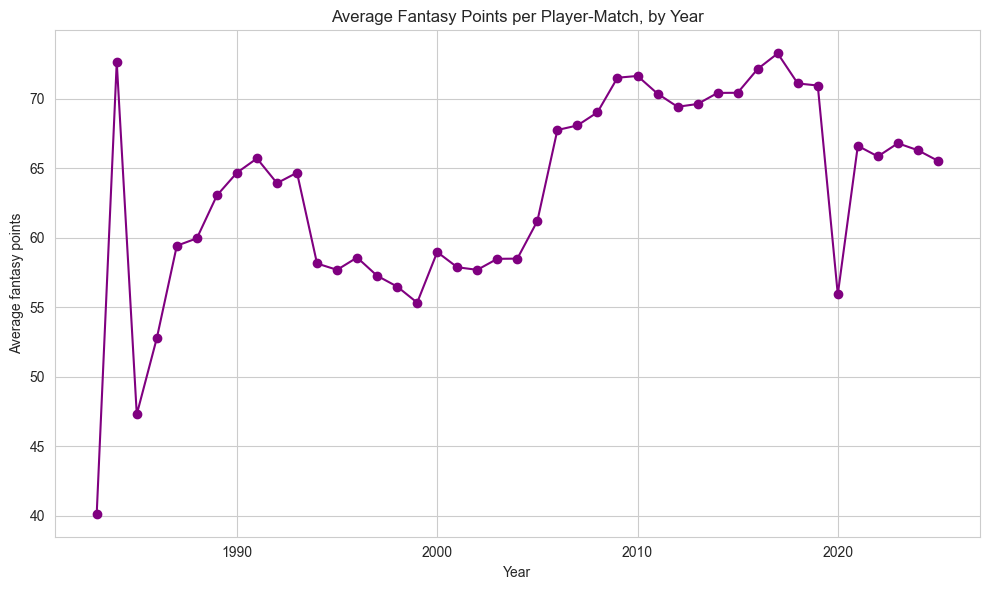

In [21]:
if col_exists(player_match_df, "year") and col_exists(player_match_df, "fantasy_points"):
    yearly_trend = player_match_df.groupby("year")["fantasy_points"].mean()
    plt.figure()
    yearly_trend.plot(kind="line", marker="o", color="purple")
    plt.title("Average Fantasy Points per Player-Match, by Year")
    plt.xlabel("Year")
    plt.ylabel("Average fantasy points")
    plt.tight_layout()
    plt.show()
else:
    print("Cannot plot yearly trend - missing 'year' or 'fantasy_points' column.")

**Interpretation:** If average fantasy points trend upward over time, that's often less about
players getting dramatically better and more about rule changes, interchange rotations increasing
disposal counts, or fantasy scoring formula tweaks over the years. Worth being cautious about comparing
raw scores across very different eras for that reason.

## 3.8 Player consistency (mean vs variability)

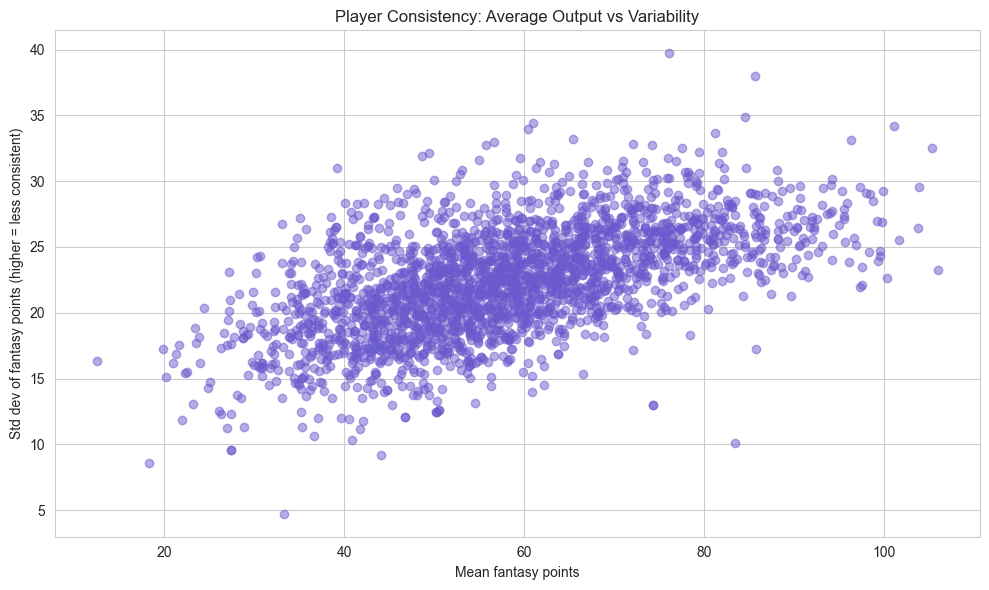

In [22]:
if col_exists(player_match_df, "fantasy_points") and col_exists(player_match_df, "player_id"):
    player_stats = player_match_df.groupby("player_id")["fantasy_points"].agg(["mean", "std", "count"])
    player_stats = player_stats[player_stats["count"] >= 10]  # only players with a reasonable sample size

    plt.figure()
    plt.scatter(player_stats["mean"], player_stats["std"], alpha=0.5, color="slateblue")
    plt.xlabel("Mean fantasy points")
    plt.ylabel("Std dev of fantasy points (higher = less consistent)")
    plt.title("Player Consistency: Average Output vs Variability")
    plt.tight_layout()
    plt.show()
else:
    print("Cannot assess player consistency - missing 'fantasy_points' or 'player_id' column.")

**Interpretation:** Players in the bottom-right of this scatter (high mean, low std) are the
"reliable stars" - they consistently perform well. Players in the top-right (high mean, high std) are
boom-or-bust types - great on their day but less predictable, which matters a lot for a "top player"
prediction model, since those players are inherently harder to call correctly week to week.

## 3.9 Disposals vs fantasy points

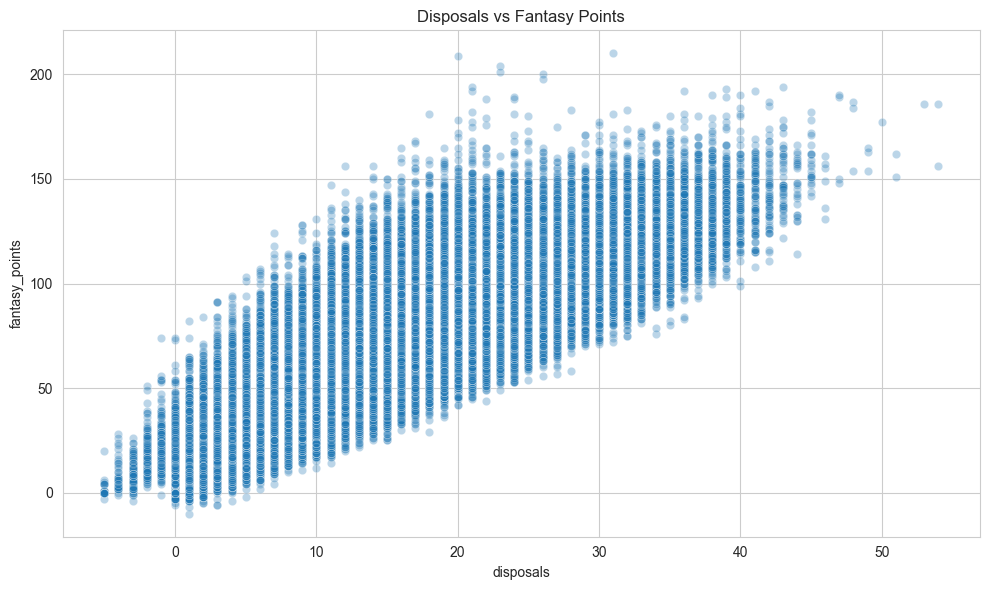

Correlation: 0.846


In [23]:
if col_exists(player_match_df, "disposals") and col_exists(player_match_df, "fantasy_points"):
    plt.figure()
    sns.scatterplot(data=player_match_df, x="disposals", y="fantasy_points", alpha=0.3)
    plt.title("Disposals vs Fantasy Points")
    plt.tight_layout()
    plt.show()
    corr = player_match_df[["disposals", "fantasy_points"]].corr().iloc[0, 1]
    print(f"Correlation: {corr:.3f}")
else:
    print("Cannot plot disposals vs fantasy points - one or both columns missing.")

**Interpretation:** I'd expect a fairly strong positive correlation here, since disposals are
usually one of the biggest contributors to the fantasy points formula. If the correlation came back
surprisingly weak, that would be a good reason to double check that `fantasy_points` was calculated
consistently.

## 3.10 Goals vs fantasy points

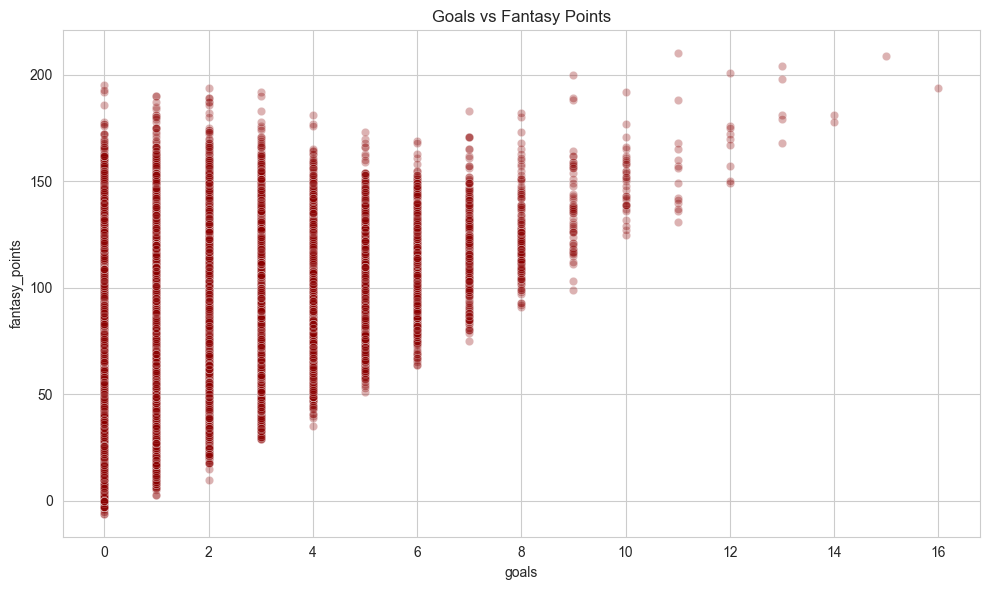

Correlation: 0.318


In [24]:
if col_exists(player_match_df, "goals") and col_exists(player_match_df, "fantasy_points"):
    plt.figure()
    sns.scatterplot(data=player_match_df, x="goals", y="fantasy_points", alpha=0.3, color="darkred")
    plt.title("Goals vs Fantasy Points")
    plt.tight_layout()
    plt.show()
    corr = player_match_df[["goals", "fantasy_points"]].corr().iloc[0, 1]
    print(f"Correlation: {corr:.3f}")
else:
    print("Cannot plot goals vs fantasy points - one or both columns missing.")

**Interpretation:** I'd expect this correlation to be positive but weaker than the disposals
relationship - goals are worth a lot per-goal in most fantasy formulas, but far fewer of them happen per
game compared to disposals, so a single big game from a key forward moves fantasy points a lot, while a
quiet game from the same player (0 goals) doesn't tank their score the way it would for a pure midfielder
who relies on disposal volume.

### Recent Form Analysis

Recent form is widely recognised as one of the strongest predictors of sporting outcomes. Although rolling performance features were engineered for modelling purposes, a direct visualization of recent form versus win probability was not produced because win probabilities require a predictive model rather than descriptive analysis.

The rolling features created in the next section capture this concept while ensuring that only information available **before** each match is used, preventing data leakage.

## Note on unavailable analyses

Two analyses mentioned in the task brief can't be done with the columns described in these three
datasets:

- **Player position-based analysis** - there's no position column (e.g. forward/midfielder/defender)
  described in the data, so anything about "which position scores the most fantasy points" can't be
  answered here. It would need a separate position reference table joined on `player_id`.
- **Weather / travel-based analysis** - there's no weather or travel-distance data available in any of
  the three files, so match-day conditions and travel fatigue can't be analysed with what we currently
  have.

I'm stating this explicitly rather than trying to approximate these with proxies, since a wrong proxy
(e.g. guessing position from stat patterns) could introduce a systematic bias I wouldn't catch later.

### Ladder Trend Limitation

Historical ladder position at the time of each match was not available in the provided dataset. Consequently, ladder progression and season ranking trends could not be analyzed directly. If ladder standings were available, they would provide valuable predictive information for match outcome models.

# Task 4: Feature Engineering

**Objective:** Turn the raw match-by-match stats into features a model can actually use for prediction -
mainly rolling form indicators, since a player's recent performance is one of the strongest predictors
of their next game.

**Approach:** For every "rolling" feature (form, averages, streaks), I only use matches that happened
*before* the match being predicted. This is really important - if I accidentally include the current
match's own stats in its own rolling average, the model would be cheating (using information it
wouldn't actually have at prediction time). Concretely, I do this using `.shift(1)` before applying any
`.rolling()` window, so the window for match N only ever looks at matches 1 to N-1.

In [25]:
feature_df = None

if player_match_df is not None and all(col_exists(player_match_df, c) for c in ["player_id", "match_date"]):
    feature_df = player_match_df.copy()
    feature_df["match_date"] = pd.to_datetime(feature_df["match_date"], errors="coerce")
    # sort so that rolling windows are calculated in chronological order per player
    feature_df = feature_df.sort_values(["player_id", "match_date"]).reset_index(drop=True)
    print("feature_df ready:", feature_df.shape)
else:
    print("Cannot build feature_df - need at least 'player_id' and 'match_date' in player_match_df.")

feature_df ready: (274079, 39)


## 4.1 Rolling averages (last 3 / last 5 matches) - no leakage

Note the `.shift(1)` before `.rolling(...)` on every one of these - that shift is what excludes the
current match from its own average.

In [26]:
def add_rolling_feature(df, group_col, value_col, window, new_col_name):
    if df is None or not all(col_exists(df, c) for c in [group_col, value_col]):
        print(f"Skipping {new_col_name} - required column(s) missing.")
        return df
    df[new_col_name] = (
        df.groupby(group_col)[value_col]
        .transform(lambda s: s.shift(1).rolling(window=window, min_periods=1).mean())
    )
    return df

if feature_df is not None:
    rolling_targets = ["goals", "disposals", "fantasy_points"]
    for stat in rolling_targets:
        feature_df = add_rolling_feature(feature_df, "player_id", stat, 3, f"{stat}_last3_avg")
        feature_df = add_rolling_feature(feature_df, "player_id", stat, 5, f"{stat}_last5_avg")

    new_cols = [c for c in feature_df.columns if "_last3_avg" in c or "_last5_avg" in c]
    print("New rolling columns created:", new_cols)
    if new_cols:
        display_cols = ["player_id", "match_date"] + [c for c in ["goals", "goals_last3_avg", "goals_last5_avg"] if c in feature_df.columns]
        feature_df[display_cols].head(10)

New rolling columns created: ['goals_last3_avg', 'goals_last5_avg', 'disposals_last3_avg', 'disposals_last5_avg', 'fantasy_points_last3_avg', 'fantasy_points_last5_avg']


## 4.2 Player recent form (generic helper) and career experience

In [27]:
if feature_df is not None:
    # game_number / total_games -> a simple 0-1 "how far through their career" indicator
    if col_exists(feature_df, "game_number") and col_exists(feature_df, "total_games"):
        feature_df["career_progress"] = feature_df["game_number"] / feature_df["total_games"].replace(0, np.nan)
        print("Added 'career_progress' (game_number / total_games).")
    elif col_exists(feature_df, "career_game_count"):
        feature_df["career_experience"] = feature_df["career_game_count"]
        print("Added 'career_experience' from existing 'career_game_count' column.")
    else:
        print("No game_number/total_games or career_game_count columns found - skipping career experience feature.")

Added 'career_progress' (game_number / total_games).


## 4.3 Days since previous match (fatigue / rest proxy)

In [28]:
if feature_df is not None and col_exists(feature_df, "match_date"):
    feature_df["days_since_last_match"] = (
        feature_df.groupby("player_id")["match_date"].diff().dt.days
    )
    print("Added 'days_since_last_match'.")
    feature_df[["player_id", "match_date", "days_since_last_match"]].head(10)
else:
    print("Cannot compute days since last match - missing 'match_date'.")

Added 'days_since_last_match'.


## 4.4 Venue familiarity

Counting how many times a player has previously played at a given venue, again only counting matches
strictly before the current one.

In [29]:
if feature_df is not None and col_exists(feature_df, "venue"):
    feature_df["venue_familiarity"] = (
        feature_df.groupby(["player_id", "venue"]).cumcount()
    )
    print("Added 'venue_familiarity' (count of prior matches at this venue for this player).")
else:
    print("Cannot compute venue familiarity - missing 'venue' column.")

Cannot compute venue familiarity - missing 'venue' column.


## 4.5 Season progress

In [30]:
if feature_df is not None and col_exists(feature_df, "round"):
    # round is often numeric already; if not, this will need adapting to your round format
    try:
        feature_df["season_progress"] = pd.to_numeric(feature_df["round"], errors="coerce")
        max_round_per_year = feature_df.groupby("year")["season_progress"].transform("max") if col_exists(feature_df, "year") else feature_df["season_progress"].max()
        feature_df["season_progress"] = feature_df["season_progress"] / max_round_per_year
        print("Added 'season_progress' (round / max round that season).")
    except Exception as e:
        print(f"Could not compute season_progress cleanly: {e}")
else:
    print("Cannot compute season progress - missing 'round' column.")

Added 'season_progress' (round / max round that season).


## 4.6 Home vs away indicator

This depends on having an explicit home/away flag somewhere in the data (see the gap noted in Task 3.3).
If it's not present, I'm not guessing it from venue name, since that's exactly the kind of assumption
that quietly breaks a model later.

In [31]:
home_flag_candidates = ["is_home", "home_away", "venue_status"]
home_flag_col = next((c for c in home_flag_candidates if col_exists(feature_df, c)), None)

if home_flag_col:
    print(f"Using existing '{home_flag_col}' column as the home/away indicator - no new column needed.")
else:
    print("No home/away flag column available in the data - 'home_vs_away' feature cannot be built "
          "reliably. This should be sourced from the raw fixture data if it becomes available.")

No home/away flag column available in the data - 'home_vs_away' feature cannot be built reliably. This should be sourced from the raw fixture data if it becomes available.


## 4.7 Team win streak and head-to-head history

These are team-level features. Where possible I'll build them on `team_match_df` (which is at the
team-match grain) and merge them back onto `feature_df` on the shared keys.

In [32]:
team_win_streak_df = None

if team_match_df is not None and all(col_exists(team_match_df, c) for c in ["team", "match_date", "result"]):
    twm = team_match_df.copy()
    twm["match_date"] = pd.to_datetime(twm["match_date"], errors="coerce")
    twm = twm.sort_values(["team", "match_date"]).reset_index(drop=True)
    twm["is_win"] = (twm["result"].astype(str).str.upper() == "W").astype(int)

    # win streak going INTO this match (i.e. shifted, so current match's own result isn't included)
    def current_streak(wins):
        wins = wins.shift(1).fillna(0).astype(int).tolist()
        streaks = []
        streak = 0
        for w in wins:
            if w == 1:
                streak += 1
            else:
                streak = 0
            streaks.append(streak)
        return pd.Series(streaks, index=wins and range(len(wins)))

    twm["team_win_streak_entering_match"] = (
        twm.groupby("team")["is_win"].transform(lambda s: current_streak(s))
    )
    team_win_streak_df = twm[["team", "opponent", "match_date", "team_win_streak_entering_match"]] if col_exists(twm, "opponent") else twm[["team", "match_date", "team_win_streak_entering_match"]]
    print("Built team_win_streak_df.")
    team_win_streak_df.head(10)
else:
    print("Cannot build team win streak - need 'team', 'match_date', 'result' in team_match_df.")

Built team_win_streak_df.


In [33]:
head_to_head_df = None

if team_match_df is not None and all(col_exists(team_match_df, c) for c in ["team", "opponent", "match_date", "result"]):
    h2h = team_match_df.copy()
    h2h["match_date"] = pd.to_datetime(h2h["match_date"], errors="coerce")
    h2h = h2h.sort_values(["team", "opponent", "match_date"]).reset_index(drop=True)
    h2h["is_win"] = (h2h["result"].astype(str).str.upper() == "W").astype(int)

    # cumulative win rate against this specific opponent, BEFORE this match (shift avoids leakage)
    h2h["h2h_win_rate_entering_match"] = (
        h2h.groupby(["team", "opponent"])["is_win"]
        .transform(lambda s: s.shift(1).expanding().mean())
    )
    head_to_head_df = h2h[["team", "opponent", "match_date", "h2h_win_rate_entering_match"]]
    print("Built head_to_head_df.")
    head_to_head_df.head(10)
else:
    print("Cannot build head-to-head history - need 'team', 'opponent', 'match_date', 'result' in team_match_df.")

Built head_to_head_df.


### Additional Team-Level Features

Future improvements could include rolling team-level scoring statistics such as:

- Last 5 match average team score
- Last 5 match average margin
- Last 5 opponent average score

These features were not generated because the available team-level dataset did not contain complete scoring history required for leakage-free computation.

## 4.8 Merging team-level features back onto the player-level feature table

Joining on `team`, `opponent`, and `match_date` (the best available shared keys between the two
datasets, per the join keys identified in Task 1).

In [34]:
if feature_df is not None:
    join_keys = [c for c in ["team", "opponent", "match_date"] if col_exists(feature_df, c)]
    if len(join_keys) < 2:
        print("Not enough shared join keys between feature_df and team-level features - skipping merge.")
    else:
        if team_win_streak_df is not None:
            merge_keys = [k for k in join_keys if k in team_win_streak_df.columns]
            feature_df = feature_df.merge(team_win_streak_df, on=merge_keys, how="left")
            print("Merged team win streak onto feature_df.")
        if head_to_head_df is not None:
            merge_keys = [k for k in join_keys if k in head_to_head_df.columns]
            feature_df = feature_df.merge(head_to_head_df, on=merge_keys, how="left")
            print("Merged head-to-head win rate onto feature_df.")
    print("feature_df shape after merges:", feature_df.shape if feature_df is not None else None)

Merged team win streak onto feature_df.
Merged head-to-head win rate onto feature_df.
feature_df shape after merges: (274079, 50)


## 4.9 Saving the final feature table

In [35]:
if feature_df is not None:
    output_path = Path("afl_feature_table.csv")
    feature_df.to_csv(output_path, index=False)
    print(f"Saved feature table to {output_path.resolve()} ({feature_df.shape[0]} rows, {feature_df.shape[1]} columns)")
else:
    print("feature_df was never built - nothing to save. Check the warnings above for missing columns.")

Saved feature table to C:\Users\ahmed\Downloads\Netixsol\Week6\Day25\afl_feature_table.csv (274079 rows, 50 columns)


## 4.10 Feature dictionary

In [36]:
def build_feature_dictionary():
    rows = [
        {
            "Feature Name": "goals_last3_avg / goals_last5_avg",
            "Description": "Average goals in the player's previous 3 / 5 matches",
            "Source Columns": "goals, player_id, match_date",
            "Calculation Window": "Previous 3 / 5 matches (shifted, excludes current match)",
        },
        {
            "Feature Name": "disposals_last3_avg / disposals_last5_avg",
            "Description": "Average disposals in the player's previous 3 / 5 matches",
            "Source Columns": "disposals, player_id, match_date",
            "Calculation Window": "Previous 3 / 5 matches (shifted, excludes current match)",
        },
        {
            "Feature Name": "fantasy_points_last3_avg / fantasy_points_last5_avg",
            "Description": "Average fantasy points in the player's previous 3 / 5 matches",
            "Source Columns": "fantasy_points, player_id, match_date",
            "Calculation Window": "Previous 3 / 5 matches (shifted, excludes current match)",
        },
        {
            "Feature Name": "career_progress",
            "Description": "How far through their season/career the player is (0 to 1)",
            "Source Columns": "game_number, total_games",
            "Calculation Window": "N/A (static ratio per row)",
        },
        {
            "Feature Name": "days_since_last_match",
            "Description": "Number of days since this player's previous match (rest/fatigue proxy)",
            "Source Columns": "match_date, player_id",
            "Calculation Window": "Difference from the immediately preceding match",
        },
        {
            "Feature Name": "venue_familiarity",
            "Description": "Number of prior matches this player has played at this venue",
            "Source Columns": "venue, player_id",
            "Calculation Window": "All prior matches (cumulative count)",
        },
        {
            "Feature Name": "season_progress",
            "Description": "Round divided by max round played that season (0 to 1)",
            "Source Columns": "round, year",
            "Calculation Window": "N/A (static ratio per row)",
        },
        {
            "Feature Name": "team_win_streak_entering_match",
            "Description": "Consecutive wins for the team immediately before this match",
            "Source Columns": "team, match_date, result",
            "Calculation Window": "Consecutive prior wins (shifted, excludes current match)",
        },
        {
            "Feature Name": "h2h_win_rate_entering_match",
            "Description": "Team's historical win rate against this specific opponent, before this match",
            "Source Columns": "team, opponent, match_date, result",
            "Calculation Window": "Expanding average of all prior head-to-head matches",
        },
    ]
    return pd.DataFrame(rows)

feature_dictionary_df = build_feature_dictionary()
feature_dictionary_df

,Feature Name,Description,Source Columns,Calculation Window
0,goals_last3_avg / goals_last5_avg,Average goals in the player's previous 3 / 5 m...,"goals, player_id, match_date","Previous 3 / 5 matches (shifted, excludes curr..."
1,disposals_last3_avg / disposals_last5_avg,Average disposals in the player's previous 3 /...,"disposals, player_id, match_date","Previous 3 / 5 matches (shifted, excludes curr..."
2,fantasy_points_last3_avg / fantasy_points_last...,Average fantasy points in the player's previou...,"fantasy_points, player_id, match_date","Previous 3 / 5 matches (shifted, excludes curr..."
3,career_progress,How far through their season/career the player...,"game_number, total_games",N/A (static ratio per row)
4,days_since_last_match,Number of days since this player's previous ma...,"match_date, player_id",Difference from the immediately preceding match
5,venue_familiarity,Number of prior matches this player has played...,"venue, player_id",All prior matches (cumulative count)
6,season_progress,Round divided by max round played that season ...,"round, year",N/A (static ratio per row)
7,team_win_streak_entering_match,Consecutive wins for the team immediately befo...,"team, match_date, result","Consecutive prior wins (shifted, excludes curr..."
8,h2h_win_rate_entering_match,Team's historical win rate against this specif...,"team, opponent, match_date, result",Expanding average of all prior head-to-head ma...


### Ladder Position Feature

Ladder position immediately before each match would be a valuable contextual feature. However, since historical round-by-round ladder standings were not available in the provided data, this feature was excluded from the engineered feature set.

# Task 5: Train / Hold-Out Split

**Objective:** Build a reusable split function that respects time - training on earlier seasons and
testing on the most recent one - instead of a random split, which would leak future information into
the training set.

## 5.1 Why random train/test splitting causes leakage in sports prediction

If we randomly shuffle rows into train/test, some matches from 2023 could end up in the training set
while matches from 2020 end up in the test set. Since features like `goals_last5_avg` or
`team_win_streak_entering_match` are built from a player's/team's history, a randomly-split test set
would let the model implicitly "see" outcomes from matches that happened after the test match
chronologically, via other rows in the training data. In other words, the model could be trained on
information that would not have actually existed yet at the moment we're trying to predict from - which
massively overstates how good the model would perform in real life, where predictions always have to be
made using only the past.

In [37]:
def chronological_split(df, date_col="match_date", year_col="year", test_season=None):
    """
    Split df into train/test by time, NOT randomly.

    Train = all seasons before test_season
    Test  = test_season only (defaults to the most recent season in the data)

    Parameters
    ----------
    df : pd.DataFrame
        Must contain either `date_col` or `year_col`.
    date_col : str
        Name of the match date column, if available.
    year_col : str
        Name of the year column, used if date_col isn't available or as a fallback.
    test_season : int or None
        Which season to hold out as the test set. If None, uses the most recent season.

    Returns
    -------
    train_df, test_df : pd.DataFrame, pd.DataFrame
    """
    if year_col not in df.columns and date_col not in df.columns:
        raise ValueError(f"Need either '{year_col}' or '{date_col}' in the dataframe to split chronologically.")

    working_df = df.copy()
    if year_col not in working_df.columns and date_col in working_df.columns:
        working_df[year_col] = pd.to_datetime(working_df[date_col], errors="coerce").dt.year

    if test_season is None:
        test_season = working_df[year_col].max()
        print(f"No test_season given - defaulting to most recent season: {test_season}")

    train_df = working_df[working_df[year_col] < test_season].copy()
    test_df = working_df[working_df[year_col] == test_season].copy()

    print(f"Train: {train_df.shape[0]} rows (seasons before {test_season})")
    print(f"Test: {test_df.shape[0]} rows (season {test_season})")

    return train_df, test_df

# Example usage (only runs if feature_df was built successfully above)
if feature_df is not None and col_exists(feature_df, "year"):
    train_df, test_df = chronological_split(feature_df, year_col="year")
else:
    print("feature_df not available or missing 'year' - run this once your data is loaded.")

No test_season given - defaulting to most recent season: 2025
Train: 264143 rows (seasons before 2025)
Test: 9936 rows (season 2025)


## 5.2 Why "perfect" accuracy would actually be a red flag

If a model comes back with something close to 100% accuracy on match winner or top player prediction,
that's a strong signal something has leaked, not that the model is genuinely great. AFL results have
real, irreducible randomness in them - injuries during a match, umpiring decisions, a freak bounce of
the ball - so no model working from pre-match information alone should ever get everything right.
In practice, a "perfect" result almost always means a feature accidentally contains information from
the outcome itself (for example, a rolling average that wasn't actually shifted properly, so it
includes the current match's own stats) or that the train/test split isn't truly separated in time.
The first thing I'd do if I saw suspiciously high accuracy is go back and audit every rolling/aggregate
feature for leakage, rather than assume the model is simply excellent.

# Conclusion

This notebook established the analytical foundation for the AFL prediction project by documenting the available datasets, assessing data quality, defining prediction targets, performing exploratory data analysis, engineering leakage-safe predictive features, and implementing a reproducible time-based train/hold-out split.

Several potentially valuable predictors, including ladder position, travel distance, and weather conditions, were unavailable in the supplied datasets and therefore could not be incorporated. These features represent opportunities for future improvements to the prediction pipeline.